In [2]:
# notebooks/02_Pipeline_A_2D-CNN_Log-Mel.ipynb
# --- 1. SETUP E CONFIGURAZIONE (CORRETTO PER GOOGLE COLAB) ---
import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import tensorflow as tf
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


# --- MODIFICHE PER COLAB ---

# 1. Monta Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # Aggiungo force_remount per sicurezza


# Definisci i percorsi conosciuti
known_paths = [
    '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab', # Percorso luke
    '/content/drive/MyDrive/Colab/urbanSmartSound_Colab'   # Percorso mirko
]


# 2. Definisci il percorso radice del tuo progetto su Google Drive
#PROJECT_ROOT = '/content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab'

# 3. Aggiungi la cartella del progetto (che contiene 'src') al path di Python
#if PROJECT_ROOT not in sys.path:
    #sys.path.append(PROJECT_ROOT)


# Prova ogni percorso conosciuto finché non ne trovi uno valido
PROJECT_ROOT = None
for path in known_paths:
    if os.path.exists(path):
        PROJECT_ROOT = path
        break

if PROJECT_ROOT:
    print(f"Trovata cartella di progetto valida a: {PROJECT_ROOT}")
    os.chdir(PROJECT_ROOT)
    sys.path.append(PROJECT_ROOT)
    !ls
else:
    print("ERRORE: Nessuno dei percorsi conosciuti è valido.")
    # Come fallback, chiedi all'utente di inserirlo manualmente
    PROJECT_ROOT = input("Per favore, incolla il percorso completo alla cartella 'urbanSmartSound_Colab': ")
    if os.path.exists(PROJECT_ROOT):
        os.chdir(PROJECT_ROOT)
        sys.path.append(PROJECT_ROOT)
        !ls
    else:
        print("Il percorso inserito non è valido.")




# Ora puoi importare i tuoi moduli
from src import data_loader, models, evaluation

# --- FINE MODIFICHE PER COLAB ---

# Configurazione specifica della pipeline
PIPELINE_NAME = "Pipeline_A_Log-Mel"
FEATURE_KEY = 'log_mel_spec'
FEATURE_LOADER_FN = data_loader.load_feature
MODEL_CREATOR_FN = models.create_advanced_2d_cnn_3gru_model
MODEL_FILENAME = "model_A_logmel.keras"
METADATA_FILENAME = "model_A_logmel_metadata.json"

# === CORREZIONE DEFINITIVA DI TUTTI I PERCORSI ===
# Usa os.path.join con PROJECT_ROOT per creare percorsi assoluti e robusti
FEATURES_DIR = os.path.join(PROJECT_ROOT, "data/processed/features_v2")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
CSV_PATH = os.path.join(PROJECT_ROOT, "data/raw/UrbanSound8K.csv")
# ================================================

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"--- ESECUZIONE: {PIPELINE_NAME} ---")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Features Directory: {FEATURES_DIR}") # Ora stamperà il percorso completo
print(f"Models Directory: {MODELS_DIR}")
print(f"CSV File Path: {CSV_PATH}")


# --- 2. CARICAMENTO DATI ---
print("\n[Fase 1/5] Caricamento di tutti i dati...")
all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(FEATURES_DIR, "fold*")))
for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"Caricando {fold_name}...")
    X_fold, y_fold = data_loader.collect_fold_data(
        fold_dir, FEATURE_LOADER_FN, feature_key=FEATURE_KEY
    )
    all_data[fold_name] = (X_fold, y_fold)
print("Caricamento completato.")


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 14653901476465431208
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8154981933210670289
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
]
Mounted at /content/drive
Trovata cartella di progetto valida a: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab
data  models  notebooks  src
--- ESECUZIONE: Pipeline_A_Log-Mel ---
Project Root: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab
Features Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/processed/features_v2
Models Directory: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models
CSV File Path: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/data/raw/UrbanSound8K.csv

[Fase 1/5] Caricamento di tutti i 

In [ ]:
# --- 3. CROSS-VALIDATION (AGGIORNATO PER FOCAL LOSS) ---
print("\n[Fase 2/5] Avvio Cross-Validation...")
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)
input_shape = list(all_data.values())[0][0][0].shape

fold_accuracies = []
all_y_true_cv, all_y_pred_cv = [], []

for i, val_fold_name in enumerate(sorted(all_data.keys())):
    print(f"\n--- CV Fold {i+1}/{len(all_data)} (Validation: {val_fold_name}) ---")

    X_val, y_val = all_data[val_fold_name]
    train_folds = [data for name, data in all_data.items() if name != val_fold_name]
    X_train = np.vstack([f[0] for f in train_folds])
    y_train = np.concatenate([f[1] for f in train_folds])

    # --- Conversione a one-hot per la Focal Loss ---
    y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
    y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

    model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)

    history = model.fit(
        X_train, y_train_one_hot,
        validation_data=(X_val, y_val_one_hot),
        epochs=50,
        batch_size=32,
        #callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )

    _, acc = model.evaluate(X_val, y_val_one_hot, verbose=0)
    fold_accuracies.append(acc)
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    all_y_true_cv.extend(y_val)
    all_y_pred_cv.extend(y_pred)
    print(f"Accuracy del fold: {acc:.4f}")

mean_acc_cv = np.mean(fold_accuracies)
std_acc_cv = np.std(fold_accuracies)
print(f"\nAccuracy media CV: {mean_acc_cv:.4f} ± {std_acc_cv:.4f}")


[Fase 2/5] Avvio Cross-Validation...

--- CV Fold 1/10 (Validation: fold1) ---
Epoch 1/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.3322 - loss: 2.0209 - val_accuracy: 0.4613 - val_loss: 1.6126
Epoch 2/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5788 - loss: 1.2351 - val_accuracy: 0.5607 - val_loss: 1.2385
Epoch 3/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6913 - loss: 0.9005 - val_accuracy: 0.6224 - val_loss: 0.9836
Epoch 4/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7574 - loss: 0.7149 - val_accuracy: 0.5638 - val_loss: 1.1443
Epoch 5/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8035 - loss: 0.6148 - val_accuracy: 0.6056 - val_loss: 1.0855
Epoch 6/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8359 - loss: 0.5005 - val_accuracy: 0.5743 - val_loss: 1.1671
Epoch 7/50
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8579 - loss: 0.4304 - val_accuracy: 0.5858 - val_loss: 1.2859
Epoch 8/50
281/28

In [3]:
# --- 4. ADDESTRAMENTO MODELLO FINALE (AGGIORNATO PER FOCAL LOSS) ---
print("\n[Fase 3/5] Addestramento del modello finale su split 80/20...")
X_train_final, y_train_final, X_test_final, y_test_final = data_loader.get_train_test_split_from_folds(
    all_data,
    meta_file_path=CSV_PATH,
    test_size=0.2
)

# Definisci i parametri dopo aver creato lo split
input_shape = X_train_final[0].shape
class_names = data_loader.get_class_map(CSV_PATH)
num_classes = len(class_names)

# --- Conversione a one-hot per la Focal Loss ---
y_train_one_hot = tf.keras.utils.to_categorical(y_train_final, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_final, num_classes=num_classes)

# Crea il modello ottimizzato
final_model = MODEL_CREATOR_FN(input_shape=input_shape, num_classes=num_classes)
final_model.summary()

# Addestra il modello
final_history = final_model.fit(
    X_train_final, y_train_one_hot,
    validation_data=(X_test_final, y_test_one_hot),
    epochs=100,
    batch_size=32,
    callbacks=[
        #EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
    ],
    verbose=1
)


[Fase 3/5] Addestramento del modello finale su split 80/20...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 173, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 173, 64)   │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 173, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 86, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 43, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 21, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 21, 256)        │     1,672,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,196,106 (8.38 MB)

 Trainable params: 2,195,466 (8.38 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 36s 125ms/step - accuracy: 0.2763 - loss: 0.4132 - val_accuracy: 0.4344 - val_loss: 0.3230 - learning_rate: 3.0000e-04
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.5046 - loss: 0.2581 - val_accuracy: 0.4516 - val_loss: 0.3465 - learning_rate: 3.0000e-04
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.5973 - loss: 0.1957 - val_accuracy: 0.5623 - val_loss: 0.2356 - learning_rate: 3.0000e-04
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.6890 - loss: 0.1483 - val_accuracy: 0.5545 - val_loss: 0.2573 - learning_rate: 3.0000e-04
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.7344 - loss: 0.1226 - val_accuracy: 0.5634 - val_loss: 0.2721 - learning_rate: 3.0000e-04
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.7910 - loss: 0.0941 - val_accuracy: 0.6290 - val_loss: 0.2000 - learning_rate: 3.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━


[Fase 4/5] Valutazione del modello finale...
Performance finale sul Test Set:
  - Loss: 0.0996
  - Accuracy: 0.8404

Generazione del report di classificazione e della matrice di confusione...
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

--- Report di Classificazione Dettagliato ---
                  precision    recall  f1-score   support

 air_conditioner       0.69      0.95      0.80       196
        car_horn       0.96      0.95      0.96       159
children_playing       0.87      0.75      0.81       182
        dog_bark       0.78      0.94      0.85       159
        drilling       0.85      0.75      0.79       169
   engine_idling       0.77      0.65      0.71       225
        gun_shot       0.95      0.99      0.97       237
      jackhammer       0.83      0.73      0.78       174
           siren       0.90      0.85      0.87       155
    street_music       0.89      0.86      0.87       142

        accuracy                           0.84      1798
       macro avg      

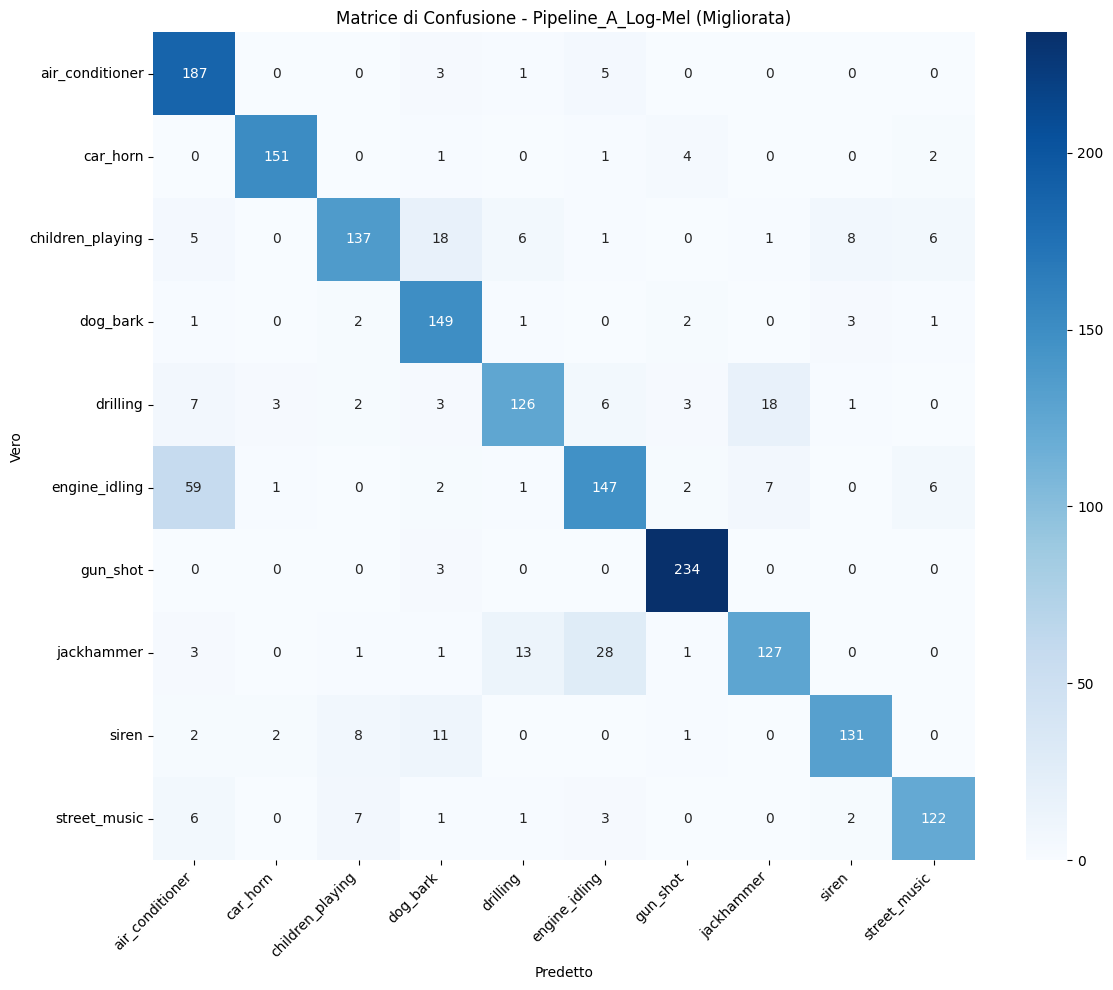


[Fase 5/5] Salvataggio del modello e dei metadati...
Modello salvato in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_A_logmel.keras
Metadati salvati in: /content/drive/MyDrive/AI_FETA/Project/urbanSmartSound_Colab/models/model_A_logmel_metadata.json


In [6]:
# --- 5. VALUTAZIONE DETTAGLIATA E SALVATAGGIO ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
print("\n[Fase 4/5] Valutazione del modello finale...")

# Valutazione di base
final_loss, final_accuracy = final_model.evaluate(X_test_final, y_test_one_hot, verbose=0)
print(f"Performance finale sul Test Set:")
print(f"  - Loss: {final_loss:.4f}")
print(f"  - Accuracy: {final_accuracy:.4f}\n")

# Report dettagliato e Matrice di Confusione
print("Generazione del report di classificazione e della matrice di confusione...")
y_pred_probs = final_model.predict(X_test_final)
y_pred_final = np.argmax(y_pred_probs, axis=1)

print("\n--- Report di Classificazione Dettagliato ---")
print(classification_report(y_test_final, y_pred_final, target_names=class_names))

print("\n--- Matrice di Confusione ---")
conf_matrix = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice di Confusione - {PIPELINE_NAME} (Migliorata)')
plt.xlabel('Predetto')
plt.ylabel('Vero')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n[Fase 5/5] Salvataggio del modello e dei metadati...")
# Salva modello
model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)
final_model.save(model_path)
print(f"Modello salvato in: {model_path}")

# Salva metadati
metadata = {
    "pipeline_name": PIPELINE_NAME,
    "feature_key": FEATURE_KEY,
    "model_architecture": "Tuned 2D-CNN + 2xBiGRU",
    "model_filename": MODEL_FILENAME,
    "input_shape": input_shape,
    "num_classes": num_classes,
    "class_names": class_names,
    #"cv_performance": {"mean_accuracy": mean_acc_cv, "std_accuracy": std_acc_cv},
    "final_test_performance": {"accuracy": final_accuracy, "loss": final_loss}
}
metadata_path = os.path.join(MODELS_DIR, METADATA_FILENAME)
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"Metadati salvati in: {metadata_path}")